# Notebook 02 — PPO-CF: the counterfactual oracle inside the training loop

Notebook 01 established plain PPO. This one adds the counterfactual action
values of the plan and compares against plain PPO under identical
hyperparameters.

**Eq (3) — the oracle.** $Q_g$ is the discounted *return* after forcing an
action, then following the behaviour policy:

$$Q_g^{\pi_{old}}(s,a) = \mathbb{E}\Big[\textstyle\sum_{\ell\ge0}\gamma^\ell r_{t+\ell}\ \Big|\ s_t=s,\ do(a_t=a),\ \pi_{old}\ \text{thereafter}\Big]$$

estimated by branching from saved simulator states and averaging fixed
continuations, with common random numbers across actions.

> **This is not $r + \gamma V_\phi(s')$.** The one-step substitution was tried
> first and failed: DoorKey's reward is purely terminal, so it contained reward
> in **0.54%** of states, correlated **+0.098** with the GAE advantage, and
> pointed at an action the policy never takes in **37%** of states. Training on
> it degraded the policy monotonically. `cf_reward_coverage` is logged every
> update so the same degeneracy cannot happen silently again.

**Eq (4) — centering on the behaviour policy:**
$A_{CF}(s,a) = Q_g(s,a) - \sum_{a'}\pi_{old}(a'|s)Q_g(s,a')$, so
$\sum_a \pi_{old}(a|s)A_{CF}(s,a)=0$ exactly.

**Eq (5) — the all-action surrogate:**

$$L_{CF} = -\frac{1}{|B|}\sum_{s}\sum_a \pi_{old}(a|s)\min\!\big(r_\theta(s,a)A_{CF},\ \mathrm{clip}(r_\theta,1\pm\varepsilon)A_{CF}\big)$$

**Eq (6) — the actor loss is a weighted SUM, not a replacement.** The two weights are independent (`ppo.alpha_gae`, `ppo.alpha_cf`) so either term can be moved on its own; 0.5 / 0.5 is the plan's convex case:

$$L_{actor} = \alpha_{gae}L_{PPO} + \alpha_{cf}L_{CF}, \qquad \alpha_{gae}=\alpha_{cf}=0.5$$

Because $Q_g$ is affordable on only a subsample of states, the blend is applied
per row where a counterfactual exists; rows without one get plain PPO, so the
arms are identical wherever the oracle is silent.

The critic is trained on GAE returns in **both** arms — only the policy loss
changes.

> **Section 1 runs the oracle checks. Do not skip to training.** Exactness and
> informativeness are different properties, and the one-step version passed
> every exactness check while being useless.

---
## ▶ Knobs

In [1]:
# ----------------------------------------------------------------------------
# EDIT ME
# ----------------------------------------------------------------------------
ENV_CONFIG    = "doorkey5x5_cf"   # doorkey5x5_cf | doorkey6x6_cf | doorkey8x8_cf
SEEDS         = [1,]              # None -> use the config's seeds
FORCE_RETRAIN = True

RUN_ORACLE_CHECKS = True          # section 1. Cheap. Run it.
RUN_CONTROL       = True          # section 2, arm A: plain PPO (pg_mode = gae)
RUN_CF            = True          # section 3, arm B: PPO-CF (pg_mode = cf_all_action)
RUN_SHUFFLED      = True          # section 3, arm C: shuffled-oracle control (the P1 gate)

# The oracle checks validate against a POLICY. A trained one makes the sanity
# probes meaningful (a random policy's critic is noise, so A_CF is too).
# Points at notebook 01's plain 5x5 run; set to None to use a fresh model.
ORACLE_CHECK_RUN  = "doorkey5x5"
ORACLE_CHECK_CKPT = 1.00

OVERRIDES = {
    # "ppo.cf_restore": "fast",     # ~2.5x quicker; section 1.5 verifies it is identical
    # "ppo.total_timesteps": 100_000,
}
# ----------------------------------------------------------------------------

In [2]:
# Reload edited modules automatically. Note this still cannot add a field to
# an already-imported dataclass -- for config schema changes, restart the kernel.
%load_ext autoreload
%autoreload 2

import sys, pathlib, time

ROOT = pathlib.Path.cwd()
if not (ROOT / "config").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config import make_config, seed_dir, RUNS_DIR, FIGURES_DIR
from dataio import load_trajectories, load_checkpoint, list_checkpoints
from utils.logging import read_scalars
from utils.plotting import plot_subgoal_ladder, savefig
from scripts.train import run_seeds

base = make_config(ENV_CONFIG, **OVERRIDES)
if SEEDS is not None:
    base = make_config(ENV_CONFIG, **{**OVERRIDES, "run.seeds": tuple(SEEDS)})
SEEDS = tuple(base.run.seeds)
STEM  = base.run.run_name

# ONE config, two arms. Every hyperparameter is shared by construction; the only
# difference between the runs is the policy gradient.
# Three arms, per the plan's P1: PPO, PPO+oracle, and PPO+SHUFFLED oracle.
# The shuffled arm gets the same oracle vectors assigned to different batch
# states. It is the gate: if it reproduces the benefit, the benefit was never
# counterfactual information, just the extra gradient structure.
ARMS = {
    k: make_config(ENV_CONFIG, **{**OVERRIDES, "run.seeds": SEEDS,
                                  "ppo.pg_mode": m, "run.run_name": f"{STEM}_{k}"})
    for k, m in [("gae", "gae"), ("cf", "cf_all_action"), ("shuf", "cf_shuffled")]
}
FIG = FIGURES_DIR / f"nb02_{STEM}"
FIG.mkdir(parents=True, exist_ok=True)

print(ARMS["cf"].summary())
print(f"\narms: {[c.run.run_name for c in ARMS.values()]}   seeds: {list(SEEDS)}")

# Measured on DoorKey-5x5, K=7: gae ~2,050 steps/s, cf ~465 ("exact") / ~1,150 ("fast")
# measured on 5x5 with H=16, R=2, subsample 10%
rate = {"gae": 2600, "cf": 300, "shuf": 300}
print("\nestimated runtime")
for k, c in ARMS.items():
    m = c.ppo.total_timesteps / rate[k] / 60
    print(f"  {k:3s}  {m:5.1f} min/seed  x {len(SEEDS)} seeds = {m*len(SEEDS):5.1f} min")

config             doorkey5x5_cf
env                MiniGrid-DoorKey-5x5-v0  (n_envs=16, obs_norm=image)
layouts            random every episode
total_timesteps    250,000  per seed
rollout batch      2048  (16 envs x 128 steps)
updates            122
minibatch size     256  x 4 epochs
gamma / lambda     0.99 / 0.95
lr                 0.001  (anneal=False)
encoder            cnn  (shared=True)
entropy            fixed, coef 0.01
prob floor         0.0 -> 0.0  (0 = off)
adv norm           batch  (min_std 1e-06)
policy gradient    cf_all_action  alpha_gae=1.0 alpha_cf=0.5, Q_g horizon=16 x2 rollouts, subsample=10%, restore=fast
reward shaping     off
warm start         none
seeds              [1]
checkpoints at     ['10%', '30%', '50%', '75%', '100%']

arms: ['dk5x5_gae', 'dk5x5_cf', 'dk5x5_shuf']   seeds: [1]

estimated runtime
  gae    1.6 min/seed  x 1 seeds =   1.6 min
  cf    13.9 min/seed  x 1 seeds =  13.9 min
  shuf   13.9 min/seed  x 1 seeds =  13.9 min


---
# 1. Test the oracle

Five checks. The first is the one that matters; the rest catch subtler things.

In [ ]:
from envs.env_pool import set_sim_state
from oracle.online import (OnlineOracle, check_replay, check_centering,
                           check_restore_equivalence, landscape_summary)

cfg = ARMS["cf"]
ENV_KW = {"fully_observable": cfg.env.fully_observable} if cfg.env.env_id.startswith("MiniGrid") else {}
K = 7 if cfg.env.env_id.startswith("MiniGrid") else None

# States and a policy to check against.
if ORACLE_CHECK_RUN and (seed_dir(ORACLE_CHECK_RUN, SEEDS[0]) / "trajectories.npz").exists():
    sd   = seed_dir(ORACLE_CHECK_RUN, SEEDS[0])
    traj = load_trajectories(sd / "trajectories.npz")
    ck   = load_checkpoint([p for p in list_checkpoints(sd / "checkpoints")
                            if abs(load_checkpoint(p).fraction - ORACLE_CHECK_CKPT) < 1e-6][0])
    value_fn, probs_fn = ck.values, ck.probs
    src = f"{ORACLE_CHECK_RUN} @ {ORACLE_CHECK_CKPT:.0%}"
    N = min(600, len(traj))
    sims  = traj.sim_state[:N]
    acts  = traj.action[:N]
    rews  = traj.reward[:N]
    nsims = traj.next_sim_state[:N]
    K = traj.n_actions
else:
    from agents.ppo import PPOTrainer
    _t = PPOTrainer(cfg, seed=SEEDS[0], progress=False)
    _t.pool.reset(); _t.collect_rollout()
    T, NE = cfg.ppo.n_steps, cfg.env.n_envs
    f = lambda a: a[:T].reshape((T*NE,) + a.shape[2:])
    sims, acts, rews, nsims = f(_t.buffer.sim_state), f(_t.buffer.actions), f(_t.buffer.rewards), f(_t.buffer.next_sim_state)
    # `_t=_t` binds the trainer AT DEFINITION TIME. Without it the lambda closes
    # over the NAME `_t`, and any later cell that rebinds it -- section 1.2 used
    # `_t` as the throwaway for `terminated` in `env.step()` -- silently turns
    # this probe into a bool. Symptom: "'bool' object has no attribute 'model'",
    # and only when the cells are run in that order.
    value_fn, probs_fn = _t._values_np, lambda o, _t=_t: _t.model.action_probs(
        __import__("torch").as_tensor(_t._scale(o), dtype=__import__("torch").float32)).numpy()
    K = _t.pool.n_actions
    src = "a fresh, untrained model (sanity probes below will be meaningless)"

print(f"checking against: {src}")
print(f"states: {len(sims)},  actions: {K},  gamma: {cfg.ppo.gamma}")

oracle = OnlineOracle(cfg.env.env_id, K, cfg.ppo.gamma, ENV_KW,
                      cfg.env.max_episode_steps, restore=cfg.ppo.cf_restore)

/opt/homebrew/anaconda3/envs/workbench/lib/python3.10/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


checking against: a fresh, untrained model (sanity probes below will be meaningless)
states: 2048,  actions: 7,  gamma: 0.99


### 1.1 Restore and replay must be exact

Restore each recorded simulator state, replay the action that was actually
taken, and compare against what the run recorded. **This is the check that
matters.** If it fails, every $A_{CF}$ in the project is meaningless and every
downstream number will look plausible and be wrong.

In [4]:
rep = check_replay(oracle, sims[:400], acts[:400], rews[:400], nsims[:400])
print(f"  transitions replayed  {rep['n']}")
print(f"  max reward error      {rep['max_reward_error']:.3e}")
print(f"  max state error       {rep['max_state_error']:.3e}")
print(f"  -> {'EXACT' if rep['exact'] else 'MISMATCH — STOP, do not train'}")

  transitions replayed  400
  max reward error      0.000e+00
  max state error       0.000e+00
  -> EXACT


### 1.2 Step count must be restored, not zeroed

`oracle/counterfactual.py` (the frozen-checkpoint oracle for NB02) restores with
`elapsed_steps=0`. On MountainCar that is harmless — every reward is −1. On
MiniGrid it is **not**: DoorKey pays `1 − 0.9·(step_count/max_steps)` on success,
so zeroing the step count makes a counterfactual success at step 200 look worth
1.0 instead of 0.72, and it also disables MiniGrid's internal truncation.

`oracle/online.py` restores the state's own step count. The cell below measures
what the difference actually is on your data.

In [ ]:
late = sims[np.argsort(sims[:, -1])[-300:]]          # the states with the highest step_count
t_ok = oracle.transitions(late)
r_bad = np.zeros_like(t_ok["reward"])
for m, s in enumerate(late):
    for a in range(K):
        set_sim_state(oracle.env, s, elapsed_steps=0)      # the NB02 behaviour
        _o, r, _term, _trunc, _ = oracle.env.step(a)   # NOT `_t`: that is the trainer
        r_bad[m, a] = r

succ = t_ok["terminated"]
print(f"  step_count range in these states : {late[:,-1].min():.0f} - {late[:,-1].max():.0f}")
print(f"  counterfactual successes among them: {int(succ.sum())}")
if succ.sum():
    ok, bad = t_ok['reward'][succ].mean(), r_bad[succ].mean()
    print(f"  mean reward, step_count restored : {ok:.4f}")
    print(f"  mean reward, elapsed_steps = 0   : {bad:.4f}   ({bad/max(ok,1e-9):.2f}x inflated)")
else:
    print("  no counterfactual successes in this sample — try a later checkpoint")

  step_count range in these states : 109 - 127
  counterfactual successes among them: 0
  no counterfactual successes in this sample — try a later checkpoint


### 1.3 Policy centering

$\sum_a \pi(a|s) A_{CF}(s,a) = 0$ must hold to floating-point precision, per
state. It is what makes the all-action gradient unbiased with respect to action
sampling; if it drifts, the loss acquires a state-dependent bias term and the
whole construction is unsound. The trainer logs this every update as
`cf_centering` and it should stay at zero for the entire run.

In [ ]:
# Recover the observation in each state the same way training does, then pi(.|s).
obs0 = np.stack([set_sim_state(oracle.env, s, elapsed_steps=int(s[-1])) for s in sims[:300]])
pi = probs_fn(obs0)
print(f"behaviour policy recovered for {len(pi)} states; centering is checked in 1.4")


behaviour policy recovered for 300 states; centering is checked in 1.4


### 1.4 Is the landscape non-degenerate, and does it say sensible things?

Two different questions. *Non-degenerate*: do the actions actually differ, or is
$A_{CF}$ flat (which is what NB02 found at MountainCar's 30% checkpoint, where
the critic was a literal constant)? *Sensible*: in DoorKey, `drop` (4) and
`done` (6) can never help, so a correct oracle over a competent policy should
rank them below average almost everywhere. That is a probe, not a gate — but if
it fails on a trained policy, suspect the oracle before the environment.

In [ ]:
# Eq (3): branch, FORCE a, follow pi for cf_horizon steps, average over
# cf_rollouts continuations with common random numbers. NOT r + gamma*V(s').
a_cf, q_cf, diag = oracle.a_g(
    sims[:300], pi[:300], probs_fn, value_fn,
    horizon=cfg.ppo.cf_horizon, n_rollouts=cfg.ppo.cf_rollouts,
    bootstrap_tail=cfg.ppo.cf_bootstrap_tail, chunk=cfg.ppo.cf_branch_envs)
c = check_centering(a_cf, pi[:300])

print("INFORMATIVENESS -- does Q_g contain any actual reward?")
print(f"  branches that saw reward         {diag['reward_coverage']:.3f}")
print(f"  branches terminating within H    {diag['terminated_within_horizon']:.3f}")
print(f"  states with reward in some branch {diag['frac_states_any_reward']:.3f}")
print("  (the one-step form measured 0.005 on this task -- that is what failed)")

s_ = landscape_summary(a_cf, q_cf, pi[:300], spread_threshold=cfg.oracle.spread_threshold,
                       useless_actions=(4, 6) if K == 7 else ())
names = ["left","right","forward","pickup","drop","toggle","done"][:K]
print(f"\nSHAPE OF THE LANDSCAPE")
print(f"  centering, max |sum pi*A_CF|     {c['max_abs']:.3e}  -> {'OK' if c['ok'] else 'BIASED'}")
print(f"  mean |A_CF|                      {s_['mean_abs_a_cf']:.4f}")
print(f"  frac states with spread > {cfg.oracle.spread_threshold}    {s_['frac_states_with_spread']:.3f}")
print(f"  all finite                       {s_['finite']}")
print("\n  best action by A_CF:")
for n, c_ in zip(names, s_["best_action_counts"]):
    print(f"    {n:8s} {c_:5d}{'   <-- useless action' if n in ('drop','done') else ''}")
if "useless_actions_negative_frac" in s_:
    print(f"\n  drop/done have A_CF < 0 in {s_['useless_actions_negative_frac']:.1%} of states")


INFORMATIVENESS -- does Q_g contain any actual reward?
  branches that saw reward         0.001
  branches terminating within H    0.001
  states with reward in some branch 0.003
  (the one-step form measured 0.005 on this task -- that is what failed)

SHAPE OF THE LANDSCAPE
  centering, max |sum pi*A_CF|     1.595e-08  -> OK
  mean |A_CF|                      0.0127
  frac states with spread > 0.01    0.913
  all finite                       True

  best action by A_CF:
    left       101
    right       85
    forward     93
    pickup      19
    drop         1   <-- useless action
    toggle       1
    done         0   <-- useless action

  drop/done have A_CF < 0 in 51.8% of states


### 1.5 `fast` restore vs `exact`, and throughput

`cf_restore: "exact"` goes through `set_sim_state`, which calls `env.reset()`
before every restore — that reset is most of the cost. `"fast"` writes the grid
and agent state directly. It is only worth having if it is **bit-identical**,
so verify rather than assume, then read the timing and decide.

In [ ]:
eq = check_restore_equivalence(cfg.env.env_id, K, cfg.ppo.gamma, sims[:250],
                               ENV_KW, cfg.env.max_episode_steps)
print(f"  max reward diff   {eq['max_reward_diff']:.3e}")
print(f"  max obs diff      {eq['max_obs_diff']:.3e}")
print(f"  terminated agree  {eq['terminated_agreement']:.3f}")
print(f"  -> {'IDENTICAL — fast is safe to use' if eq['identical'] else 'DIFFERENT — keep exact'}\n")

batch = cfg.env.n_envs * cfg.ppo.n_steps
for kind in ("exact", "fast"):
    o = OnlineOracle(cfg.env.env_id, K, cfg.ppo.gamma, ENV_KW, cfg.env.max_episode_steps, restore=kind)
    probe = sims[:min(batch, len(sims))]
    t0 = time.time(); o.q_cf(probe, value_fn); dt = time.time() - t0
    sps = len(probe) / dt
    print(f"  {kind:5s}  {sps:6.0f} collected steps/s   "
          f"-> {cfg.ppo.total_timesteps/sps/60:5.1f} min/seed at {cfg.ppo.total_timesteps:,} frames")
    o.close()
oracle.close()

  max reward diff   0.000e+00
  max obs diff      0.000e+00
  terminated agree  1.000
  -> IDENTICAL — fast is safe to use

  exact     363 collected steps/s   ->  11.5 min/seed at 250,000 frames
  fast      941 collected steps/s   ->   4.4 min/seed at 250,000 frames


### Oracle verdict

In [ ]:
checks = {
    "restore/replay is exact":                    rep["exact"],
    "A_CF is policy-centred (max < 1e-4)":        c["ok"],
    "A_CF is finite":                             s_["finite"],
    f"actions differ in > {cfg.oracle.min_frac_states_with_spread:.0%} of states":
        s_["frac_states_with_spread"] > cfg.oracle.min_frac_states_with_spread,
    "fast and exact restore agree":               eq["identical"],
    # THE GATE THAT THE ONE-STEP VERSION FAILED. Exactness says the oracle
    # computes what it claims; this says what it computes carries information.
    "Q_g contains reward (coverage > 0.02)":      diag["reward_coverage"] > 0.02,
}
w = max(len(k) for k in checks)
for k, v in checks.items():
    print(f"  {'PASS' if v else 'FAIL'}  {k:<{w}}")
print()
print("ORACLE:", "PASS — safe to train on" if all(checks.values())
      else "FAIL — fix before training; A_CF errors are invisible downstream")

  PASS  restore/replay is exact              
  PASS  A_CF is policy-centred (max < 1e-4)  
  PASS  A_CF is finite                       
  PASS  actions differ in > 20% of states    
  PASS  fast and exact restore agree         
  FAIL  Q_g contains reward (coverage > 0.02)

ORACLE: FAIL — fix before training; A_CF errors are invisible downstream


---
# 2. Arm A — plain PPO (control)

In [ ]:
def train_arm(key):
    c = ARMS[key]
    done = all((seed_dir(c.run.run_name, s) / "scalars.csv").exists() for s in c.run.seeds)
    if done and not FORCE_RETRAIN:
        print(f"found existing run at {RUNS_DIR / c.run.run_name} — skipping")
        return None
    t0 = time.time()
    out = run_seeds(c)
    print(f"\n{key}: {(time.time()-t0)/60:.1f} min total")
    return out

if RUN_CONTROL:
    train_arm("gae")



=== seed 1 ====================================================
  upd    10/122  step   20,480  ret   0.116  succ 0.27  sg1 0.98 sg2 0.50  ent 1.806  advstd 5.70e-02  ev  0.625  1,937 sps
  upd    20/122  step   40,960  ret   0.142  succ 0.31  sg1 0.96 sg2 0.59  ent 1.701  advstd 8.00e-02  ev  0.537  1,938 sps
  upd    30/122  step   61,440  ret   0.287  succ 0.56  sg1 1.00 sg2 0.78  ent 1.616  advstd 6.32e-02  ev  0.678  1,945 sps
  upd    40/122  step   81,920  ret   0.639  succ 0.95  sg1 0.99 sg2 0.98  ent 1.196  advstd 1.09e-01  ev  0.432  1,946 sps
  upd    50/122  step  102,400  ret   0.821  succ 0.99  sg1 1.00 sg2 1.00  ent 1.168  advstd 9.41e-02  ev  0.739  1,953 sps
  upd    60/122  step  122,880  ret   0.891  succ 1.00  sg1 1.00 sg2 1.00  ent 1.003  advstd 8.60e-02  ev  0.694  1,949 sps
  upd    70/122  step  143,360  ret   0.931  succ 0.99  sg1 1.00 sg2 1.00  ent 0.632  advstd 6.03e-02  ev  0.493  1,948 sps
  upd    80/122  step  163,840  ret   0.952  succ 1.00  sg1 1.00 sg

---
# 3. Arm B — PPO-CF

The first rollout prints the oracle's replay and centering check again, this
time against the live policy inside the trainer. `cf_centering` in
`scalars.csv` should read 0 on every logged update.

In [ ]:
if RUN_CF:
    train_arm("cf")

# The P1 control arm. Same oracle vectors, wrong states.
if RUN_SHUFFLED:
    train_arm("shuf")



=== seed 1 ====================================================
  oracle check: replay exact over 96 transitions (reward err 0, state err 0); centering max 2.29e-08
  upd    10/122  step   20,480  ret   0.071  succ 0.16  sg1 1.00 sg2 0.44  ent 1.850  advstd 1.65e-02  ev  0.744  359 sps
  upd    20/122  step   40,960  ret   0.126  succ 0.28  sg1 1.00 sg2 0.62  ent 1.713  advstd 6.50e-02  ev  0.412  357 sps
  upd    30/122  step   61,440  ret   0.240  succ 0.52  sg1 0.99 sg2 0.72  ent 1.657  advstd 5.60e-02  ev  0.712  357 sps
  upd    40/122  step   81,920  ret   0.536  succ 0.89  sg1 1.00 sg2 0.96  ent 1.352  advstd 9.79e-02  ev  0.487  360 sps
  upd    50/122  step  102,400  ret   0.811  succ 0.99  sg1 1.00 sg2 0.99  ent 1.275  advstd 8.61e-02  ev  0.642  367 sps
  upd    60/122  step  122,880  ret   0.885  succ 0.99  sg1 1.00 sg2 0.99  ent 1.010  advstd 8.39e-02  ev  0.656  375 sps
  upd    70/122  step  143,360  ret   0.921  succ 1.00  sg1 1.00 sg2 1.00  ent 0.782  advstd 7.54e-02 

---
# 4. Comparison

The metric is **sample efficiency**: frames to first reach
`success_rate_100 >= 0.9`. Final performance is not the axis — plain PPO already
reaches 1.00 on 5x5 — so a run that gets there sooner is the win condition.

In [ ]:
scal = {k: {s: read_scalars(seed_dir(c.run.run_name, s) / "scalars.csv")
            for s in c.run.seeds if (seed_dir(c.run.run_name, s) / "scalars.csv").exists()}
        for k, c in ARMS.items()}
scal = {k: v for k, v in scal.items() if v}

THRESH = 0.9
def frames_to(d, col="success_rate_100", thresh=THRESH):
    hit = d.loc[d[col] >= thresh, "global_step"]
    return int(hit.iloc[0]) if len(hit) else None

rows = []
for arm, per_seed in scal.items():
    for s, d in per_seed.items():
        rows.append({
            "arm": arm, "seed": s,
            f"frames_to_{THRESH:g}": frames_to(d),
            "final_success": round(float(d["success_rate_100"].iloc[-1]), 3),
            "final_subgoal2": round(float(d["subgoal2_rate_100"].iloc[-1]), 3),
            "best_success": round(float(d["success_rate_100"].max()), 3),
            "ev_median": round(float(d["explained_variance"].median()), 3),
            "kl_median": round(float(d["approx_kl"].median()), 4),
            "clipfrac_median": round(float(d["clipfrac"].median()), 3),
            "cf_coverage": (round(float(d["cf_reward_coverage"].mean()), 3)
                            if "cf_reward_coverage" in d else None),
            "cf_corr_gae": (round(float(d["cf_corr_gae"].mean()), 3)
                            if "cf_corr_gae" in d else None),
        })
cmp_df = pd.DataFrame(rows).sort_values(["arm", "seed"])
display(cmp_df)

print(f"\nmedian frames to success >= {THRESH:g}")
for arm, g in cmp_df.groupby("arm"):
    v = g[f"frames_to_{THRESH:g}"].dropna()
    print(f"  {arm:3s}  {('%.0f' % v.median()) if len(v) else 'never':>10s}"
          f"   ({len(v)}/{len(g)} seeds reached it)")

,arm,seed,frames_to_0.9,final_success,final_subgoal2,best_success,ev_median,kl_median,clipfrac_median,cf_coverage,cf_corr_gae
1,cf,1,102400,1.0,1.0,1.0,0.642,0.0086,0.089,0.468,0.153
0,gae,1,81920,1.0,1.0,1.0,0.588,0.0108,0.092,NaN,NaN
2,shuf,1,81920,1.0,1.0,1.0,0.613,0.0128,0.092,0.484,0.030



median frames to success >= 0.9
  cf       102400   (1/1 seeds reached it)
  gae       81920   (1/1 seeds reached it)
  shuf       81920   (1/1 seeds reached it)


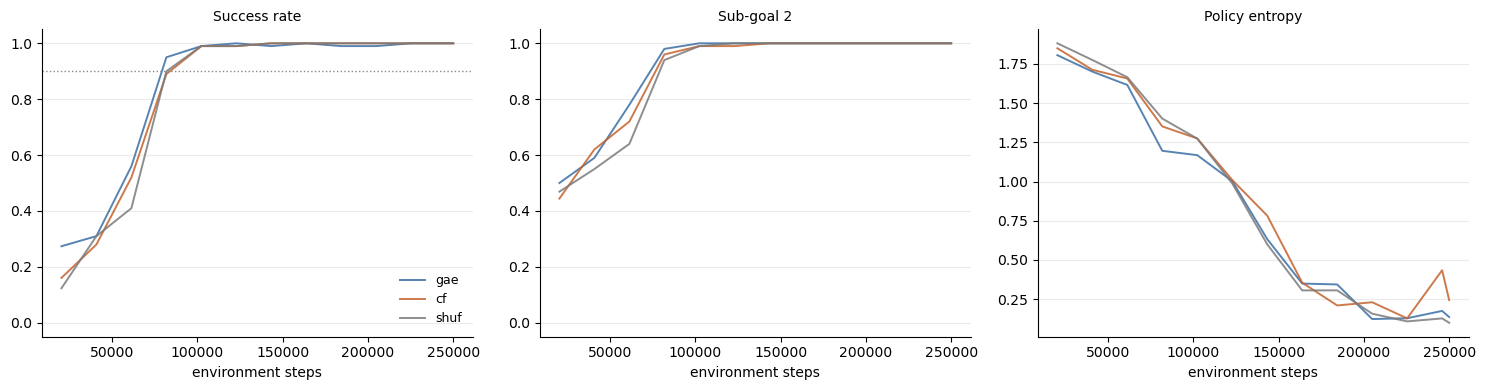

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = {"gae": "#3b6ea5", "cf": "#c4622d", "shuf": "#7a7a7a"}
panels = [("success_rate_100", "Success rate"), ("subgoal2_rate_100", "Sub-goal 2"),
          ("entropy", "Policy entropy")]
for ax, (col, title) in zip(axes, panels):
    for arm, per_seed in scal.items():
        for i, (s, d) in enumerate(per_seed.items()):
            ax.plot(d["global_step"], d[col], lw=1.4, alpha=0.85, color=colors[arm],
                    label=arm if i == 0 else None)
    ax.set_title(title, fontsize=10); ax.set_xlabel("environment steps")
    ax.spines[["top","right"]].set_visible(False); ax.grid(axis="y", alpha=0.25)
axes[0].axhline(THRESH, color="#888", ls=":", lw=1)
axes[0].set_ylim(-0.05, 1.05); axes[1].set_ylim(-0.05, 1.05)
axes[0].legend(frameon=False, fontsize=9)
fig.tight_layout(); savefig(fig, FIG / "arms.png"); plt.show()

### The confound to check before believing a win

The all-action gradient updates **all K action logits** per state, while GAE
updates only the sampled one. At the same learning rate that makes the CF arm
take *larger* policy steps — measured on a smoke run, `approx_kl` and `clipfrac`
came out roughly 3× higher for CF at the same frame count.

So if CF wins, the question is whether it won on counterfactual *information* or
just on a bigger effective step size. The panel below shows update size per arm.
If they are badly mismatched, rerun both with `ppo.target_kl: 0.03`, which caps
the per-update movement and makes the comparison KL-matched.

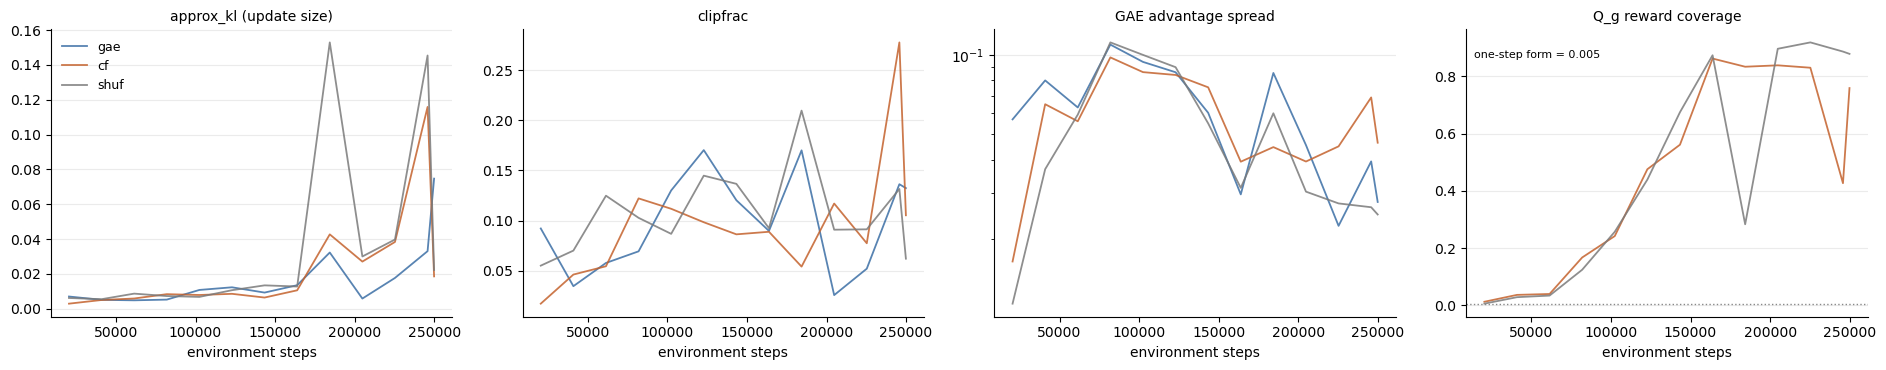


dk5x5_cf  (seed 1)
  cf_centering          max  4.894e-06   must stay ~0; above 1e-4 the all-action gradient is biased
  cf_reward_coverage   last      0.759   fraction of branches that saw reward; the one-step form was 0.005
  cf_corr_gae          mean     +0.153   corr(A_CF taken, GAE); the one-step form was +0.098
  cf_mean_abs          mean     0.5411   |A_CF| in GAE-advantage units
  cf_n_cf_states       last        205   states given a counterfactual per rollout

dk5x5_shuf  (seed 1)
  cf_centering          max  7.226e-06   must stay ~0; above 1e-4 the all-action gradient is biased
  cf_reward_coverage   last      0.878   fraction of branches that saw reward; the one-step form was 0.005
  cf_corr_gae          mean     +0.030   corr(A_CF taken, GAE); the one-step form was +0.098
  cf_mean_abs          mean     0.6857   |A_CF| in GAE-advantage units
  cf_n_cf_states       last        205   states given a counterfactual per rollout


In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(19, 3.8))
panels = [("approx_kl", "approx_kl (update size)"),
          ("clipfrac", "clipfrac"),
          ("adv_std_raw", "GAE advantage spread"),
          ("cf_reward_coverage", "Q_g reward coverage")]
for ax, (col, title) in zip(axes, panels):
    for arm, per_seed in scal.items():
        for i, (s, d) in enumerate(per_seed.items()):
            if col not in d.columns or not np.isfinite(d[col]).any():
                continue
            ax.plot(d["global_step"], d[col], lw=1.3, alpha=0.85, color=colors[arm],
                    label=arm if i == 0 else None)
    ax.set_title(title, fontsize=10); ax.set_xlabel("environment steps")
    ax.spines[["top", "right"]].set_visible(False); ax.grid(axis="y", alpha=0.25)
axes[2].set_yscale("log")
axes[3].axhline(0.005, color="#888", ls=":", lw=1)
axes[3].text(0.02, 0.9, "one-step form = 0.005", transform=axes[3].transAxes, fontsize=8)
axes[0].legend(frameon=False, fontsize=9)
fig.tight_layout(); savefig(fig, FIG / "update_size.png"); plt.show()

# PPO-CF health. Every column is checked before use: the trainer's cf_* keys
# change as the estimator changes, and a plot cell should not die on a rename.
for arm in ("cf", "shuf"):
    if arm not in scal:
        continue
    seed0 = sorted(scal[arm])[0]
    d = scal[arm][seed0]
    print(f"\n{ARMS[arm].run.run_name}  (seed {seed0})")
    checks = [
        ("cf_centering",       "max", "{:.3e}", "must stay ~0; above 1e-4 the all-action gradient is biased"),
        ("cf_reward_coverage", "last", "{:.3f}", "fraction of branches that saw reward; the one-step form was 0.005"),
        ("cf_corr_gae",        "mean", "{:+.3f}", "corr(A_CF taken, GAE); the one-step form was +0.098"),
        ("cf_mean_abs",        "mean", "{:.4f}", "|A_CF| in GAE-advantage units"),
        ("cf_n_cf_states",     "last", "{:.0f}", "states given a counterfactual per rollout"),
    ]
    for col, how, fmt, why in checks:
        if col not in d.columns or not np.isfinite(d[col]).any():
            print(f"  {col:20s} not logged")
            continue
        v = {"max": d[col].max(), "mean": d[col].mean(), "last": d[col].iloc[-1]}[how]
        print(f"  {col:20s} {how:>4} {fmt.format(v):>10}   {why}")


---
## 5. Reading the result

| outcome | what it means | next |
|---|---|---|
| CF reaches 0.9 in clearly fewer frames, KL comparable | the counterfactual advantage helps | move up a rung; then NB05's learned $B(s)$ becomes worth building |
| CF wins but its `approx_kl` is much larger | probably step size, not information | rerun both with `ppo.target_kl: 0.03` |
| arms overlap | **5x5 is too easy to discriminate**, not "the oracle fails" | move up a rung — do not tune |
| CF is clearly worse | the oracle is exact, so suspect the critic: $A_{CF}$ inherits all of $V_\phi$'s error | check `ev_median` per arm |

The rung to move to is `doorkey6x6_cf` (750k, no warm start — a controlled
comparison must not inherit a policy trained under a different gradient), then
`doorkey8x8_cf` as a **probe** rather than a controlled comparison.

8x8 is where this matters most. Plain PPO failed it outright: 3M frames, success
never above 0.06, key rate 0.85 but door rate 0.10, entropy pinned at 1.89 of
log 7 = 1.946 — the policy was held at uniform because the sampled advantage
carried no consistent signal (`adv_std_raw` ~1e-3, EV oscillating around 0). If
action-sampling variance is what killed it, the all-action oracle is exactly the
intervention that should help. Watch the **door rate**: on 6x6, once the door
opened the agent essentially always finished, so the door is where 8x8 stalls.